# 1. Imports & global config

In [2]:
# System utilities
import os
import re
from collections import Counter
from pathlib import Path

# Data & numerical
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

# Visualization
from wordcloud import WordCloud

# ML utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Notebook display
from IPython.display import display

print("TensorFlow:", tf.__version__)
nltk.download("stopwords")


TensorFlow: 2.18.1


[nltk_data] Downloading package stopwords to /home/rabby/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# 2. Fixed Hyperparameters

In [4]:
# Model Hyperparameters
EMBEDDING_DIM = 300
BATCH_SIZE = 10000
EPOCHS = 10
LR = 1e-3
MODEL_PATH = "./best_model.hdf5"

# Tokenizer Hyperparameters
MAX_WORDS = 100000
MAX_SEQ_LENGTH = 30

# 3. Data Loading 

In [6]:
DATA_PATH = "data/training.1600000.processed.noemoticon.csv"

df = pd.read_csv(
    DATA_PATH,
    header=None,
    engine="python",
    encoding="latin-1",
    encoding_errors="ignore"
)

df.columns = ["sentiment", "id", "date", "query", "user_id", "text"]
df = df[["sentiment", "text"]]

display(df.head())

,sentiment,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


# 4. EDA

## Sentiment Distribution

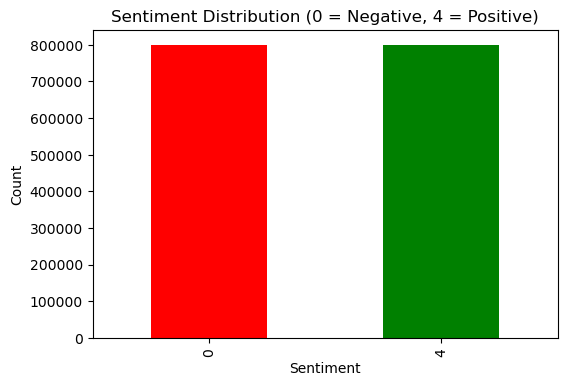

In [12]:
plt.figure(figsize=(6,4))
df['sentiment'].value_counts().plot(kind='bar', color=['red','green'])
plt.title("Sentiment Distribution (0 = Negative, 4 = Positive)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

## Tweet Length Distribution

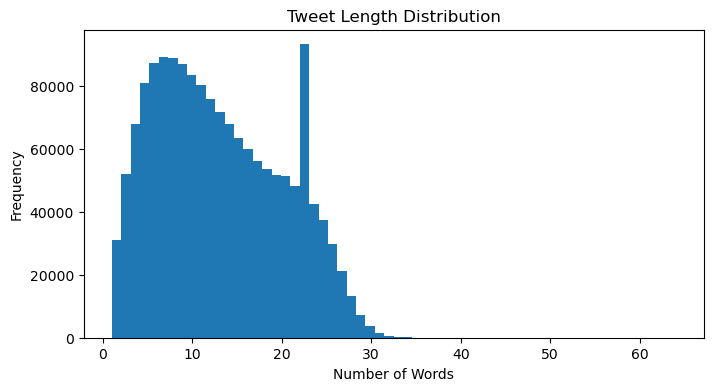

In [15]:
df["text_len"] = df["text"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,4))
plt.hist(df["text_len"], bins=60)
plt.title("Tweet Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

## WordClouds

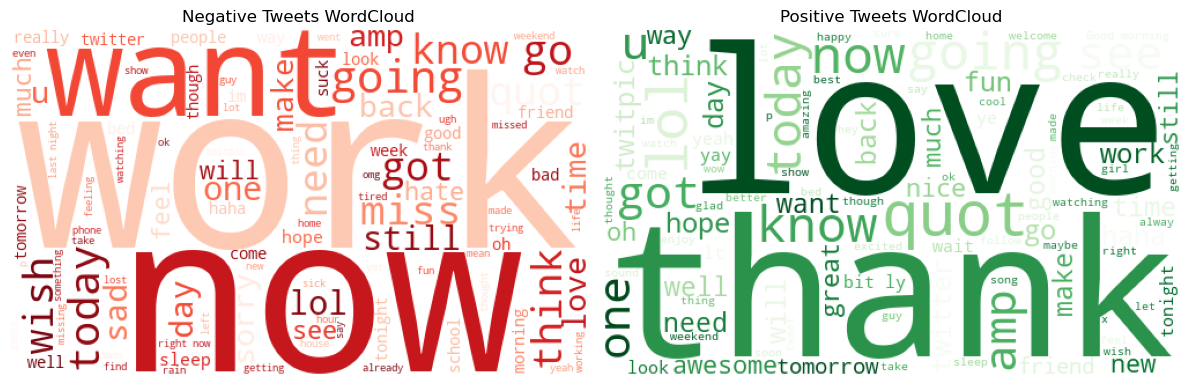

In [18]:
neg_text = " ".join(df[df["sentiment"]==0]["text"])
pos_text = " ".join(df[df["sentiment"]==4]["text"])

plt.figure(figsize=(12,5))

# Negative tweets wordcloud (red colors)
plt.subplot(1,2,1)
neg_wordcloud = WordCloud(width=500, height=300, 
                         background_color='white',
                         colormap='Reds',
                         max_words=100).generate(neg_text)
plt.imshow(neg_wordcloud)
plt.title("Negative Tweets WordCloud")
plt.axis("off")

# Positive tweets wordcloud (green colors)
plt.subplot(1,2,2)
pos_wordcloud = WordCloud(width=500, height=300, 
                         background_color='white',
                         colormap='Greens',
                         max_words=100).generate(pos_text)
plt.imshow(pos_wordcloud)
plt.title("Positive Tweets WordCloud")
plt.axis("off")

plt.tight_layout()
plt.show()

# 5. Text Preprocessing

In [21]:
stop_words = stopwords.words("english")
stemmer = SnowballStemmer("english")

clean_re = r'@\S+|https?:\S+|http?:\S|[^A-Za-z0-9]+'

def preprocess(text, stem=False):
    text = re.sub(clean_re, " ", str(text).lower()).strip()
    tokens = []
    for token in text.split():
        if token not in stop_words:
            tokens.append(stemmer.stem(token) if stem else token)
    return " ".join(tokens)

# 6. Apply Cleaning

In [24]:
df["clean_text"] = df["text"].apply(preprocess)
display(df[["text", "clean_text"]].head())

,text,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww bummer shoulda got david carr third day
1,is upset that he can't update his Facebook by ...,upset update facebook texting might cry result...
2,@Kenichan I dived many times for the ball. Man...,dived many times ball managed save 50 rest go ...
3,my whole body feels itchy and like its on fire,whole body feels itchy like fire
4,"@nationwideclass no, it's not behaving at all....",behaving mad see


# 7. Train/Test Split

In [27]:
# Split train and test sets

train_df, test_df = train_test_split(df, test_size=0.2, random_state=666, shuffle=True)

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (1280000, 4)
Test size: (320000, 4)


# 8. Tokenizer + Padding

In [30]:
tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(train_df["clean_text"])

x_train = pad_sequences(
    tokenizer.texts_to_sequences(train_df["clean_text"]),
    maxlen=MAX_SEQ_LENGTH
)

x_test = pad_sequences(
    tokenizer.texts_to_sequences(test_df["clean_text"]),
    maxlen=MAX_SEQ_LENGTH
)

y_train = (train_df["sentiment"]==4).astype(int).values
y_test  = (test_df["sentiment"]==4).astype(int).values

# 9. Load GloVe Embeddings

In [35]:
GLOVE_PATH = "data/glove.6B.300d.txt"

embedding_index = {}
with open(GLOVE_PATH, encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = vector

print("Loaded word vectors:", len(embedding_index))

Loaded word vectors: 400000


# 10 Build Embedding Matrix

In [38]:
vocab_size = len(tokenizer.word_index) + 1

embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

for word, idx in tokenizer.word_index.items():
    vec = embedding_index.get(word)
    if vec is not None and idx < vocab_size:
        embedding_matrix[idx] = vec

embedding_matrix.shape

(290683, 300)

# 11. Build RNN Model

In [6]:
model = Sequential([
    Embedding(vocab_size, EMBEDDING_DIM,
              weights=[embedding_matrix],
              input_shape=(MAX_SEQ_LENGTH,),
              trainable=False),

    SimpleRNN(128),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    metrics=["accuracy"]
)

model.summary()

NameError: name 'Sequential' is not defined

# 12. Callbacks

In [44]:
os.makedirs("saved_models", exist_ok=True)

checkpoint = ModelCheckpoint(
    filepath="saved_models/rnn_best.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

# 13. Train Model

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[checkpoint, early_stop]
)